# Module 3 — Intent Classifier

**Goal:** classify *what the customer wants* (e.g. "where is my order", "I want a refund")
so the chatbot can route the message to the right handler before the RAG module even runs.

**Dataset:** [`bitext/Bitext-customer-service-llm-chatbot-training-dataset`](https://huggingface.co/datasets/bitext/Bitext-customer-service-llm-chatbot-training-dataset)
— ~27k examples, each labeled with a fine-grained `intent` (27 values) grouped under a
native `category` field (11 values).

**Design decisions (documented for the assessment):**
- **Model choice — TF-IDF (word n-grams) + Linear SVM**, not a transformer. Intents in
  this dataset are expressed through short, fairly formulaic phrasings ("I want to
  cancel order {{Order Number}}", "how can I track my package") — a linear model on
  bag-of-n-grams features already separates these well, trains in seconds, and is much
  easier to justify/debug in the assessment than an opaque fine-tuned transformer. We
  reserve the "heavier" model budget for the module that actually needs deep semantic
  understanding (Module 2 — sentiment).
- **7-category grouping:** the dataset ships 11 native `category` values; we merge them
  into the 7 routing buckets the chatbot actually needs, so the router has a small,
  manageable action space:
    - `order_delivery`   = ORDER, DELIVERY, SHIPPING_ADDRESS, CANCELLATION_FEE
    - `payment_invoice`  = PAYMENT, INVOICE
    - `refund`           = REFUND
    - `account`          = ACCOUNT
    - `feedback`         = FEEDBACK
    - `human_handoff`    = CONTACT
    - `subscription`     = NEWSLETTER
- We train and report metrics at **both** granularities: the full 27-intent level (fine
  routing / analytics) and the 7-category level (what the router actually consumes) —
  useful talking points if asked "why not just use the categories directly".


In [1]:
# 1. Imports
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

RANDOM_STATE = 42


e:\pytorch-gpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# 2. Load dataset
raw = load_dataset("bitext/Bitext-customer-support-llm-chatbot-training-dataset")
df = raw["train"].to_pandas()
print(df.shape)
df[["instruction", "category", "intent"]].head()


e:\pytorch-gpu\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\DELL\.cache\huggingface\hub\datasets--bitext--Bitext-customer-support-llm-chatbot-training-dataset. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating train split: 100%|██████████| 26872/26872 [00:00<00:00, 51286.91 examples/s]

(26872, 5)


,instruction,category,intent
0,question about cancelling order {{Order Number}},ORDER,cancel_order
1,i have a question about cancelling oorder {{Or...,ORDER,cancel_order
2,i need help cancelling puchase {{Order Number}},ORDER,cancel_order
3,I need to cancel purchase {{Order Number}},ORDER,cancel_order
4,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order


In [4]:
# 3. Explore native categories/intents
print("Categories (11):", sorted(df['category'].unique()))
print()
print("Intents (27):", sorted(df['intent'].unique()))


Categories (11): ['ACCOUNT', 'CANCEL', 'CONTACT', 'DELIVERY', 'FEEDBACK', 'INVOICE', 'ORDER', 'PAYMENT', 'REFUND', 'SHIPPING', 'SUBSCRIPTION']

Intents (27): ['cancel_order', 'change_order', 'change_shipping_address', 'check_cancellation_fee', 'check_invoice', 'check_payment_methods', 'check_refund_policy', 'complaint', 'contact_customer_service', 'contact_human_agent', 'create_account', 'delete_account', 'delivery_options', 'delivery_period', 'edit_account', 'get_invoice', 'get_refund', 'newsletter_subscription', 'payment_issue', 'place_order', 'recover_password', 'registration_problems', 'review', 'set_up_shipping_address', 'switch_account', 'track_order', 'track_refund']


In [8]:
CATEGORY_TO_BUCKET = {
    "ORDER": "order_delivery",
    "DELIVERY": "order_delivery",
    "SHIPPING": "order_delivery",
    "CANCEL": "order_delivery",
    "PAYMENT": "payment_invoice",
    "INVOICE": "payment_invoice",
    "REFUND": "refund",
    "ACCOUNT": "account",
    "FEEDBACK": "feedback",
    "CONTACT": "human_handoff",
    "SUBSCRIPTION": "subscription",
}

df["category"] = df["category"].astype(str).str.strip().str.upper()
df["bucket"] = df["category"].map(CATEGORY_TO_BUCKET)

unmapped = df.loc[df["bucket"].isna(), "category"].unique()
print("Unmapped:", unmapped)
df["bucket"].value_counts()

Unmapped: <ArrowStringArray>
[]
Length: 0, dtype: str


bucket
order_delivery     8902
account            5986
payment_invoice    3997
refund             2992
human_handoff      1999
feedback           1997
subscription        999
Name: count, dtype: int64

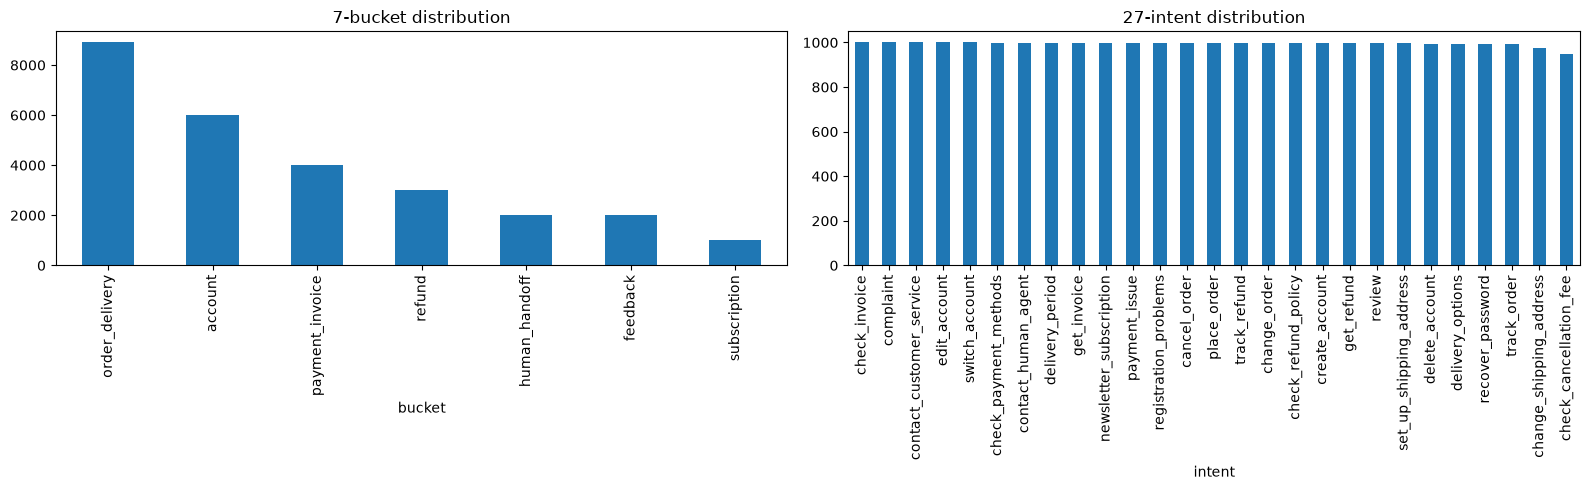

In [9]:
# 5. Class balance at both granularities
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
df["bucket"].value_counts().plot(kind="bar", ax=axes[0], title="7-bucket distribution")
df["intent"].value_counts().plot(kind="bar", ax=axes[1], title="27-intent distribution")
plt.tight_layout()
plt.show()


## 5.1 Preprocessing

Light cleaning: lowercase, strip the dataset's `{{PLACEHOLDER}}` slot tokens (e.g.
`{{Order Number}}`) down to a generic marker so the model learns the *intent phrasing*
rather than memorizing placeholder text, and strip extra whitespace/punctuation noise.

In [10]:
# 6. Preprocessing
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"\{\{.*?\}\}", " slot ", text)     # {{Order Number}} -> slot
    text = re.sub(r"[^a-z0-9\s']", " ", text)          # drop stray punctuation
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["instruction"].astype(str).apply(clean_text)
df[["instruction", "clean_text"]].sample(5, random_state=RANDOM_STATE)


,instruction,clean_text
9329,I can't talk with a human agent,i can't talk with a human agent
4160,I have got to locate hte bills from {{Person N...,i have got to locate hte bills from slot
18500,"I cannot pay, help me to inform of a problem w...",i cannot pay help me to inform of a problem wi...
8840,I want help speaking to customer service,i want help speaking to customer service
5098,I try to see th accepted payment options,i try to see th accepted payment options


In [11]:
# 7. Train/test split (stratified on the fine-grained intent to keep both levels balanced)
train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df["intent"], random_state=RANDOM_STATE
)
train_df, valid_df = train_test_split(
    train_df, test_size=0.1, stratify=train_df["intent"], random_state=RANDOM_STATE
)
len(train_df), len(valid_df), len(test_df)


(19347, 2150, 5375)

In [12]:
# 8. TF-IDF features (word n-grams — phrasing/word choice drives intent, unlike Module 1)
vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=2,
    max_features=30000,
    sublinear_tf=True,
)
X_train = vectorizer.fit_transform(train_df["clean_text"])
X_valid = vectorizer.transform(valid_df["clean_text"])
X_test  = vectorizer.transform(test_df["clean_text"])
X_train.shape


(19347, 4893)

## 8.1 Two classifiers, two granularities

We train one `LinearSVC` on the 27 fine-grained intents and one on the 7 routing
buckets. In production the router only needs the bucket-level model; the intent-level
model is useful for analytics/logging ("what exactly are people asking about inside
`order_delivery`?").

In [13]:
# 9. Encode labels for each granularity
le_intent = LabelEncoder()
y_train_intent = le_intent.fit_transform(train_df["intent"])
y_valid_intent = le_intent.transform(valid_df["intent"])
y_test_intent  = le_intent.transform(test_df["intent"])

le_bucket = LabelEncoder()
y_train_bucket = le_bucket.fit_transform(train_df["bucket"])
y_valid_bucket = le_bucket.transform(valid_df["bucket"])
y_test_bucket  = le_bucket.transform(test_df["bucket"])


In [14]:
# 10. Train the bucket-level model (this is the one the router calls)
bucket_clf = LinearSVC(random_state=RANDOM_STATE)
bucket_clf.fit(X_train, y_train_bucket)

val_pred = bucket_clf.predict(X_valid)
print("Bucket-level validation accuracy:", accuracy_score(y_valid_bucket, val_pred))


Bucket-level validation accuracy: 0.998139534883721


In [15]:
# 11. Train the intent-level model (analytics)
intent_clf = LinearSVC(random_state=RANDOM_STATE)
intent_clf.fit(X_train, y_train_intent)

val_pred_i = intent_clf.predict(X_valid)
print("Intent-level validation accuracy:", accuracy_score(y_valid_intent, val_pred_i))


Intent-level validation accuracy: 0.9911627906976744


In [16]:
# 12. Final evaluation on the held-out TEST split — bucket level (production model)
test_pred_bucket = bucket_clf.predict(X_test)
print("Bucket-level TEST accuracy:", accuracy_score(y_test_bucket, test_pred_bucket))
print("Bucket-level TEST macro-F1:", f1_score(y_test_bucket, test_pred_bucket, average="macro"))
print()
print(classification_report(y_test_bucket, test_pred_bucket, target_names=le_bucket.classes_))


Bucket-level TEST accuracy: 0.9988837209302326
Bucket-level TEST macro-F1: 0.9988256392405173

                 precision    recall  f1-score   support

        account       1.00      1.00      1.00      1197
       feedback       1.00      1.00      1.00       399
  human_handoff       1.00      1.00      1.00       400
 order_delivery       1.00      1.00      1.00      1781
payment_invoice       1.00      0.99      1.00       800
         refund       1.00      1.00      1.00       598
   subscription       1.00      0.99      1.00       200

       accuracy                           1.00      5375
      macro avg       1.00      1.00      1.00      5375
   weighted avg       1.00      1.00      1.00      5375



In [17]:
# 13. Final evaluation — intent level (analytics model)
test_pred_intent = intent_clf.predict(X_test)
print("Intent-level TEST accuracy:", accuracy_score(y_test_intent, test_pred_intent))
print("Intent-level TEST macro-F1:", f1_score(y_test_intent, test_pred_intent, average="macro"))


Intent-level TEST accuracy: 0.9951627906976744
Intent-level TEST macro-F1: 0.9951738164738093


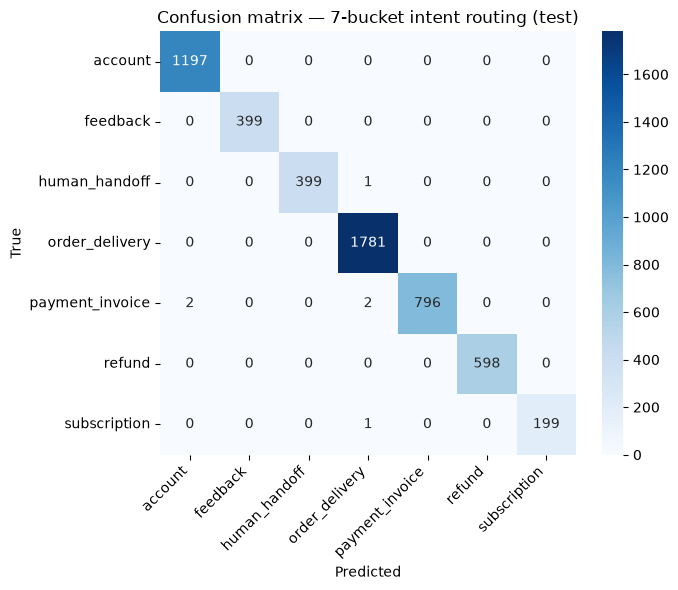

In [18]:
# 14. Confusion matrix — bucket level (what the router relies on)
cm = confusion_matrix(y_test_bucket, test_pred_bucket)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le_bucket.classes_, yticklabels=le_bucket.classes_)
plt.title("Confusion matrix — 7-bucket intent routing (test)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 15. Save artifacts for deployment

Only the **bucket-level** model needs to ship to the live router. We keep the
intent-level model too since it's cheap to store and useful for logging/analytics.

In [19]:
# 15. Persist model artifacts
joblib.dump(vectorizer, "intent_vectorizer.joblib")
joblib.dump(bucket_clf, "intent_bucket_model.joblib")
joblib.dump(le_bucket, "intent_bucket_label_encoder.joblib")
joblib.dump(intent_clf, "intent_finegrained_model.joblib")
joblib.dump(le_intent, "intent_finegrained_label_encoder.joblib")

print("Saved 5 artifacts for the intent module.")


Saved 5 artifacts for the intent module.


## 16. Inference helper

In [20]:
# 16. Predict function used by the router
def predict_intent_bucket(text: str) -> str:
    cleaned = clean_text(text)
    features = vectorizer.transform([cleaned])
    pred = bucket_clf.predict(features)
    return le_bucket.inverse_transform(pred)[0]

for sample in [
    "Where is my order? It hasn't arrived yet.",
    "I want a refund for my last purchase.",
    "Can you update my shipping address please.",
    "This service has been terrible, I want to speak to a human.",
    "How do I unsubscribe from your newsletter?",
]:
    print(f"{predict_intent_bucket(sample):18s} <- {sample}")


order_delivery     <- Where is my order? It hasn't arrived yet.
refund             <- I want a refund for my last purchase.
order_delivery     <- Can you update my shipping address please.
human_handoff      <- This service has been terrible, I want to speak to a human.
subscription       <- How do I unsubscribe from your newsletter?
